### Import Required Libraries

In [1]:
# Step 8A: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


### Define Project Paths

In [2]:
# Step 8B: Define project paths

BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

RETENTION_STRENGTH_INPUT_DIR = PROCESSED_DATA_DIR / "retention_strength_scoring"
VISUALIZATION_OUTPUT_DIR = PROCESSED_DATA_DIR / "matplotlib_visualizations"

RETENTION_STRENGTH_DATA_PATH = RETENTION_STRENGTH_INPUT_DIR / "retention_strength_master_dataset.csv"

# Create visualization output directory
VISUALIZATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Base Directory:", BASE_DIR)
print("Input Dataset Path:", RETENTION_STRENGTH_DATA_PATH)
print("Visualization Output Directory:", VISUALIZATION_OUTPUT_DIR)

Base Directory: C:\Users\Mohit\OneDrive\Documents\Data Analytics\Unified Mentor Projects\Customer Engagement & Product Utilization Analytics for Retention Strategy
Input Dataset Path: C:\Users\Mohit\OneDrive\Documents\Data Analytics\Unified Mentor Projects\Customer Engagement & Product Utilization Analytics for Retention Strategy\data\processed\retention_strength_scoring\retention_strength_master_dataset.csv
Visualization Output Directory: C:\Users\Mohit\OneDrive\Documents\Data Analytics\Unified Mentor Projects\Customer Engagement & Product Utilization Analytics for Retention Strategy\data\processed\matplotlib_visualizations


### Load Final Master Dataset

In [3]:
# Step 8C: Load final retention strength master dataset

df = pd.read_csv(RETENTION_STRENGTH_DATA_PATH)

# Preview dataset
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Churn_Status,Engagement_Status,Credit_Card_Status,Product_Depth_Segment,Balance_Segment,Salary_Segment,Age_Segment,Tenure_Segment,High_Value_Customer_Flag,High_Value_Customer_Status,High_Value_Disengaged_Flag,High_Value_Disengaged_Status,At_Risk_Premium_Flag,At_Risk_Premium_Status,Salary_Balance_Mismatch_Flag,Salary_Balance_Mismatch_Status,Customer_Risk_Segment,Relationship_Strength_Index,Relationship_Strength_Tier,High_Balance_Flag,High_Balance_Status,Retention_Priority_Segment,Retention_Strength_Score,Retention_Strength_Tier
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,"101,348.88",1,Churned,Active Member,Has Credit Card,Single Product,Zero Balance,High Salary,Mid-Age Customer,New Customer,0,Standard Value Customer,0,Not High-Value Disengaged,0,Not At-Risk Premium,0,No Salary-Balance Mismatch,Standard Monitoring,55,Moderate Relationship,0,Not High Balance,Already Churned,37.00,Weak Retention
1,2025,15647311,Hill,608,Spain,Female,41,1,"83,807.86",1,0,1,"112,542.58",0,Retained,Active Member,No Credit Card,Single Product,Medium Balance,High Salary,Mid-Age Customer,New Customer,0,Standard Value Customer,0,Not High-Value Disengaged,0,Not At-Risk Premium,0,No Salary-Balance Mismatch,Standard Monitoring,55,Moderate Relationship,0,Not High Balance,Low Priority,52.00,Weak Retention
2,2025,15619304,Onio,502,France,Female,42,8,"159,660.80",3,1,0,"113,931.57",1,Churned,Inactive Member,Has Credit Card,High Product Load,Premium Balance,High Salary,Mid-Age Customer,Established Relationship,1,High Value Customer,1,High-Value Disengaged,1,At-Risk Premium Customer,0,No Salary-Balance Mismatch,At-Risk Premium,50,Weak Relationship,1,High Balance Customer,Already Churned,45.00,Weak Retention
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,"93,826.63",0,Retained,Inactive Member,No Credit Card,Optimal Product Depth,Zero Balance,Medium Salary,Mid-Age Customer,New Customer,0,Standard Value Customer,0,Not High-Value Disengaged,0,Not At-Risk Premium,0,No Salary-Balance Mismatch,Standard Monitoring,35,Weak Relationship,0,Not High Balance,Medium Priority,34.00,Critical Retention Risk
4,2025,15737888,Mitchell,850,Spain,Female,43,2,"125,510.82",1,1,1,"79,084.10",0,Retained,Active Member,Has Credit Card,Single Product,High Balance,Medium Salary,Mid-Age Customer,New Customer,0,Standard Value Customer,0,Not High-Value Disengaged,0,Not At-Risk Premium,0,No Salary-Balance Mismatch,Standard Monitoring,75,Moderate Relationship,0,Not High Balance,Low Priority,70.00,Moderate Retention


### Dataset Shape and Column Validation

In [4]:
# Step 8D: Dataset shape and column validation

print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]:,}")

print("\nAvailable Columns:")
for col in df.columns:
    print("-", col)

required_columns = [
    "CustomerId",
    "Geography",
    "Gender",
    "Age",
    "Balance",
    "EstimatedSalary",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "Exited",
    "Churn_Status",
    "Engagement_Status",
    "Credit_Card_Status",
    "Product_Depth_Segment",
    "Customer_Risk_Segment",
    "Relationship_Strength_Index",
    "Relationship_Strength_Tier",
    "Retention_Priority_Segment",
    "Retention_Strength_Score",
    "Retention_Strength_Tier"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(missing_columns) == 0:
    print("\nAll required columns are available.")
else:
    print("\nMissing required columns:")
    print(missing_columns)

Total Rows: 10,000
Total Columns: 38

Available Columns:
- Year
- CustomerId
- Surname
- CreditScore
- Geography
- Gender
- Age
- Tenure
- Balance
- NumOfProducts
- HasCrCard
- IsActiveMember
- EstimatedSalary
- Exited
- Churn_Status
- Engagement_Status
- Credit_Card_Status
- Product_Depth_Segment
- Balance_Segment
- Salary_Segment
- Age_Segment
- Tenure_Segment
- High_Value_Customer_Flag
- High_Value_Customer_Status
- High_Value_Disengaged_Flag
- High_Value_Disengaged_Status
- At_Risk_Premium_Flag
- At_Risk_Premium_Status
- Salary_Balance_Mismatch_Flag
- Salary_Balance_Mismatch_Status
- Customer_Risk_Segment
- Relationship_Strength_Index
- Relationship_Strength_Tier
- High_Balance_Flag
- High_Balance_Status
- Retention_Priority_Segment
- Retention_Strength_Score
- Retention_Strength_Tier

All required columns are available.


### Matplotlib Global Styling

In [5]:
# Step 8E: Matplotlib global styling

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 120

print("Matplotlib styling configured successfully.")

Matplotlib styling configured successfully.


### Retention Strength Tier Distribution Chart

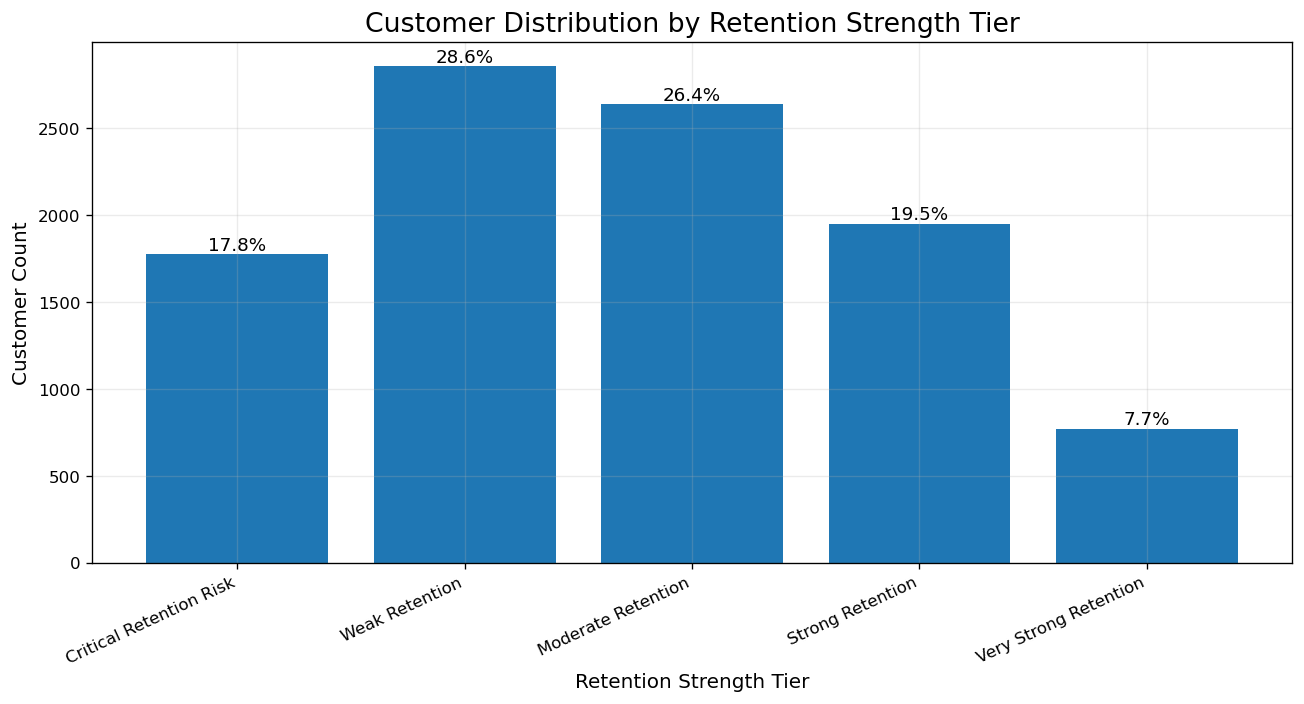

,Retention Strength Tier,Customer Count,Customer %
3,Critical Retention Risk,1776,17.76
0,Weak Retention,2857,28.57
1,Moderate Retention,2640,26.40
2,Strong Retention,1953,19.53
4,Very Strong Retention,774,7.74


In [6]:
# Step 8F: Retention Strength Tier Distribution Chart

retention_tier_distribution = (
    df["Retention_Strength_Tier"]
    .value_counts()
    .reset_index()
)

retention_tier_distribution.columns = [
    "Retention Strength Tier",
    "Customer Count"
]

retention_tier_distribution["Customer %"] = (
    retention_tier_distribution["Customer Count"] / len(df) * 100
).round(2)

tier_order = [
    "Critical Retention Risk",
    "Weak Retention",
    "Moderate Retention",
    "Strong Retention",
    "Very Strong Retention"
]

retention_tier_distribution["Retention Strength Tier"] = pd.Categorical(
    retention_tier_distribution["Retention Strength Tier"],
    categories=tier_order,
    ordered=True
)

retention_tier_distribution = retention_tier_distribution.sort_values(
    "Retention Strength Tier"
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    retention_tier_distribution["Retention Strength Tier"],
    retention_tier_distribution["Customer Count"]
)

plt.title("Customer Distribution by Retention Strength Tier")
plt.xlabel("Retention Strength Tier")
plt.ylabel("Customer Count")
plt.xticks(rotation=25, ha="right")

for bar, pct in zip(bars, retention_tier_distribution["Customer %"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    VISUALIZATION_OUTPUT_DIR / "retention_strength_tier_distribution.png",
    bbox_inches="tight"
)

plt.show()

retention_tier_distribution

### Churn Rate by Retention Strength Tier

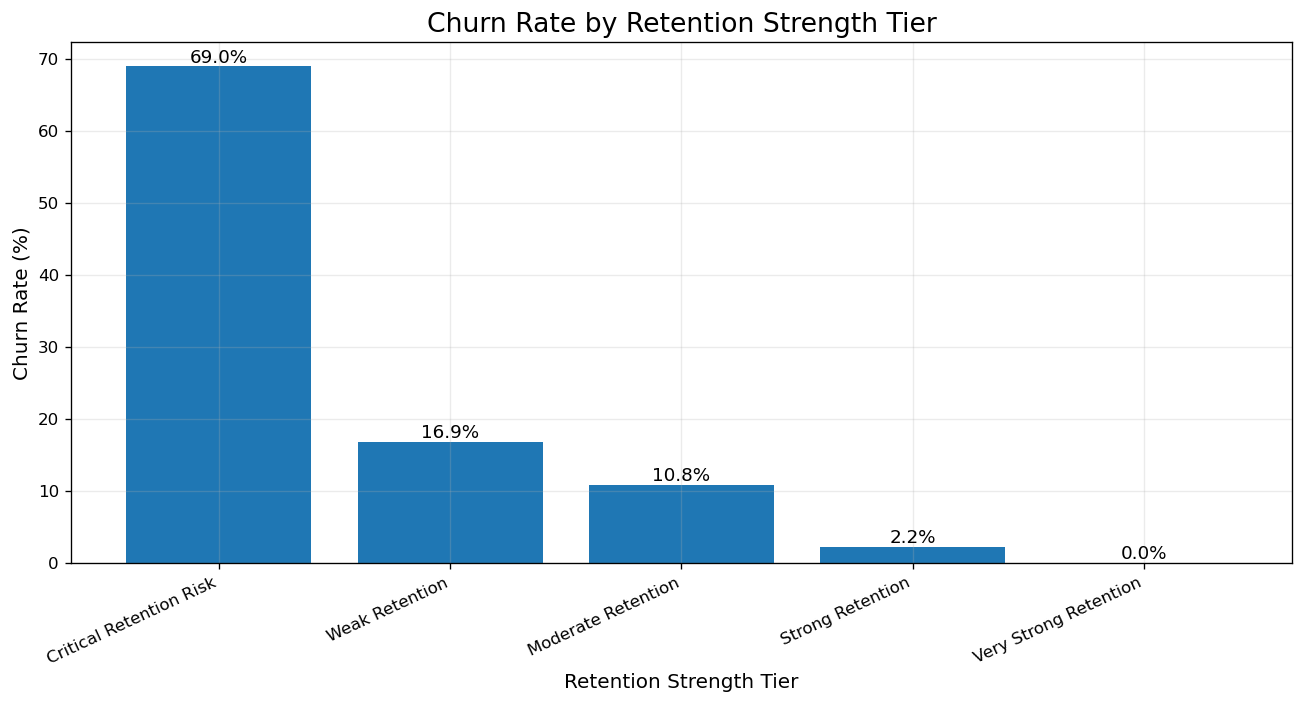

,Retention_Strength_Tier,Customer_Count,Churned_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Churn_Rate,Retention_Rate
0,Critical Retention Risk,1776,1225,20.92,40.69,68.98,31.02
4,Weak Retention,2857,482,45.95,52.81,16.87,83.13
1,Moderate Retention,2640,286,65.61,70.54,10.83,89.17
2,Strong Retention,1953,44,82.30,82.62,2.25,97.75
3,Very Strong Retention,774,0,95.49,95.23,0.00,100.00


In [7]:
# Step 8G: Churn Rate by Retention Strength Tier

retention_tier_churn = (
    df.groupby("Retention_Strength_Tier")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean")
    )
    .reset_index()
)

retention_tier_churn["Churn_Rate"] = (
    retention_tier_churn["Churned_Customers"] /
    retention_tier_churn["Customer_Count"] * 100
).round(2)

retention_tier_churn["Retention_Rate"] = (
    100 - retention_tier_churn["Churn_Rate"]
).round(2)

retention_tier_churn["Retention_Strength_Tier"] = pd.Categorical(
    retention_tier_churn["Retention_Strength_Tier"],
    categories=tier_order,
    ordered=True
)

retention_tier_churn = retention_tier_churn.sort_values(
    "Retention_Strength_Tier"
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    retention_tier_churn["Retention_Strength_Tier"],
    retention_tier_churn["Churn_Rate"]
)

plt.title("Churn Rate by Retention Strength Tier")
plt.xlabel("Retention Strength Tier")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")

for bar, rate in zip(bars, retention_tier_churn["Churn_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    VISUALIZATION_OUTPUT_DIR / "churn_rate_by_retention_strength_tier.png",
    bbox_inches="tight"
)

plt.show()

retention_tier_churn

### Engagement Status vs Churn Rate Chart

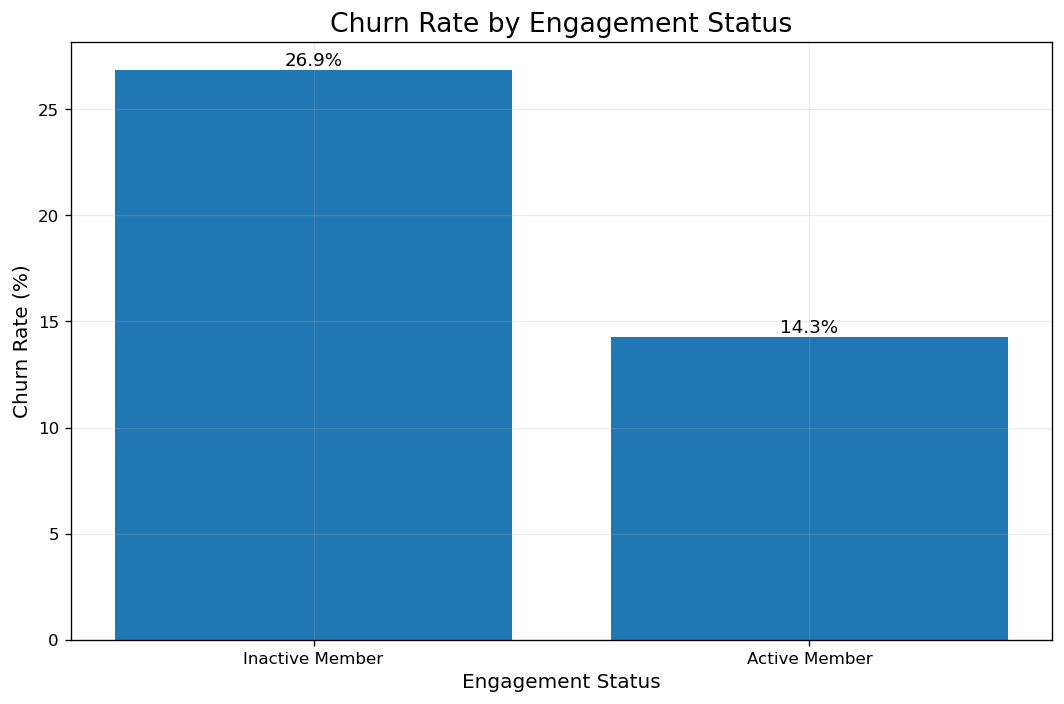

,Engagement_Status,Customer_Count,Churned_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Churn_Rate,Retention_Rate
1,Inactive Member,4849,1302,39.65,48.91,26.85,73.15
0,Active Member,5151,735,74.55,79.07,14.27,85.73


In [8]:
# Step 8H: Engagement Status vs Churn Rate Chart

engagement_churn = (
    df.groupby("Engagement_Status")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean")
    )
    .reset_index()
)

engagement_churn["Churn_Rate"] = (
    engagement_churn["Churned_Customers"] /
    engagement_churn["Customer_Count"] * 100
).round(2)

engagement_churn["Retention_Rate"] = (
    100 - engagement_churn["Churn_Rate"]
).round(2)

engagement_churn = engagement_churn.sort_values(
    "Churn_Rate",
    ascending=False
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    engagement_churn["Engagement_Status"],
    engagement_churn["Churn_Rate"]
)

plt.title("Churn Rate by Engagement Status")
plt.xlabel("Engagement Status")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(bars, engagement_churn["Churn_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    VISUALIZATION_OUTPUT_DIR / "churn_rate_by_engagement_status.png",
    bbox_inches="tight"
)

plt.show()

engagement_churn

### Product Depth vs Retention Rate Chart

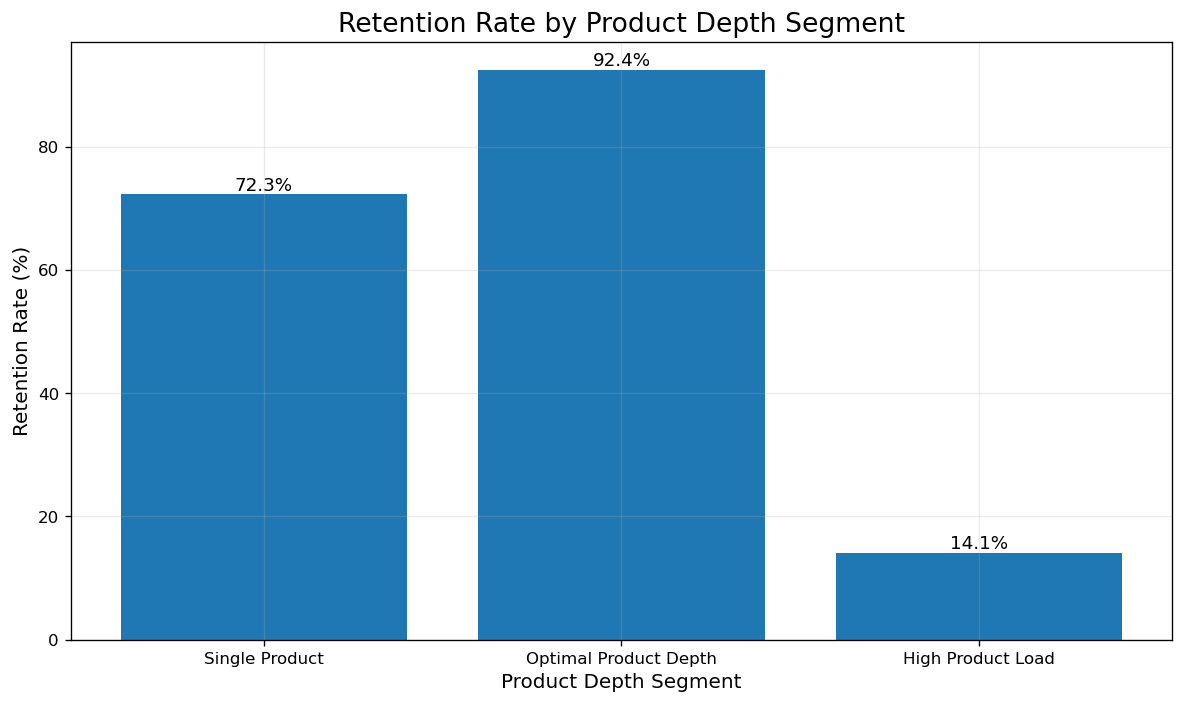

,Product_Depth_Segment,Customer_Count,Churned_Customers,Avg_Num_Products,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Churn_Rate,Retention_Rate
2,Single Product,5084,1409,1.00,48.45,58.30,27.71,72.29
1,Optimal Product Depth,4590,348,2.00,68.46,72.37,7.58,92.42
0,High Product Load,326,280,3.18,48.20,48.65,85.89,14.11


In [9]:
# Step 8I: Product Depth vs Retention Rate Chart

product_depth_retention = (
    df.groupby("Product_Depth_Segment")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Avg_Num_Products=("NumOfProducts", "mean"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean")
    )
    .reset_index()
)

product_depth_retention["Churn_Rate"] = (
    product_depth_retention["Churned_Customers"] /
    product_depth_retention["Customer_Count"] * 100
).round(2)

product_depth_retention["Retention_Rate"] = (
    100 - product_depth_retention["Churn_Rate"]
).round(2)

product_depth_order = [
    "Single Product",
    "Optimal Product Depth",
    "High Product Load"
]

product_depth_retention["Product_Depth_Segment"] = pd.Categorical(
    product_depth_retention["Product_Depth_Segment"],
    categories=product_depth_order,
    ordered=True
)

product_depth_retention = product_depth_retention.sort_values(
    "Product_Depth_Segment"
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    product_depth_retention["Product_Depth_Segment"],
    product_depth_retention["Retention_Rate"]
)

plt.title("Retention Rate by Product Depth Segment")
plt.xlabel("Product Depth Segment")
plt.ylabel("Retention Rate (%)")

for bar, rate in zip(bars, product_depth_retention["Retention_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    VISUALIZATION_OUTPUT_DIR / "retention_rate_by_product_depth_segment.png",
    bbox_inches="tight"
)

plt.show()

product_depth_retention

### Customer Risk Segment Distribution Chart

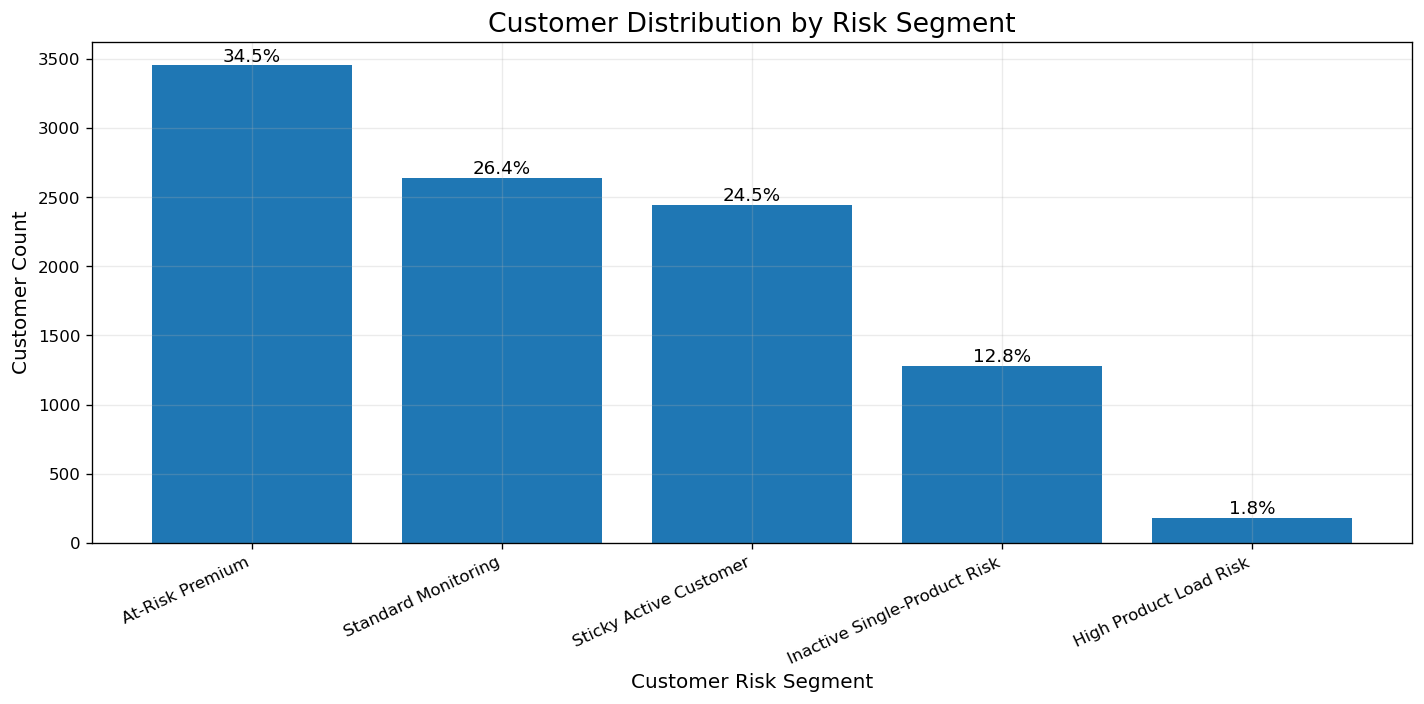

,Customer Risk Segment,Customer Count,Customer %
0,At-Risk Premium,3452,34.52
1,Standard Monitoring,2641,26.41
2,Sticky Active Customer,2446,24.46
3,Inactive Single-Product Risk,1279,12.79
4,High Product Load Risk,182,1.82


In [10]:
# Step 8J: Customer Risk Segment Distribution Chart

customer_risk_distribution = (
    df["Customer_Risk_Segment"]
    .value_counts()
    .reset_index()
)

customer_risk_distribution.columns = [
    "Customer Risk Segment",
    "Customer Count"
]

customer_risk_distribution["Customer %"] = (
    customer_risk_distribution["Customer Count"] / len(df) * 100
).round(2)

customer_risk_distribution = customer_risk_distribution.sort_values(
    "Customer Count",
    ascending=False
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    customer_risk_distribution["Customer Risk Segment"],
    customer_risk_distribution["Customer Count"]
)

plt.title("Customer Distribution by Risk Segment")
plt.xlabel("Customer Risk Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=25, ha="right")

for bar, pct in zip(bars, customer_risk_distribution["Customer %"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    VISUALIZATION_OUTPUT_DIR / "customer_risk_segment_distribution.png",
    bbox_inches="tight"
)

plt.show()

customer_risk_distribution

## Customer Risk Segment Churn Rate Chart

This chart compares churn rate across customer risk segments to identify which groups require the highest retention attention.

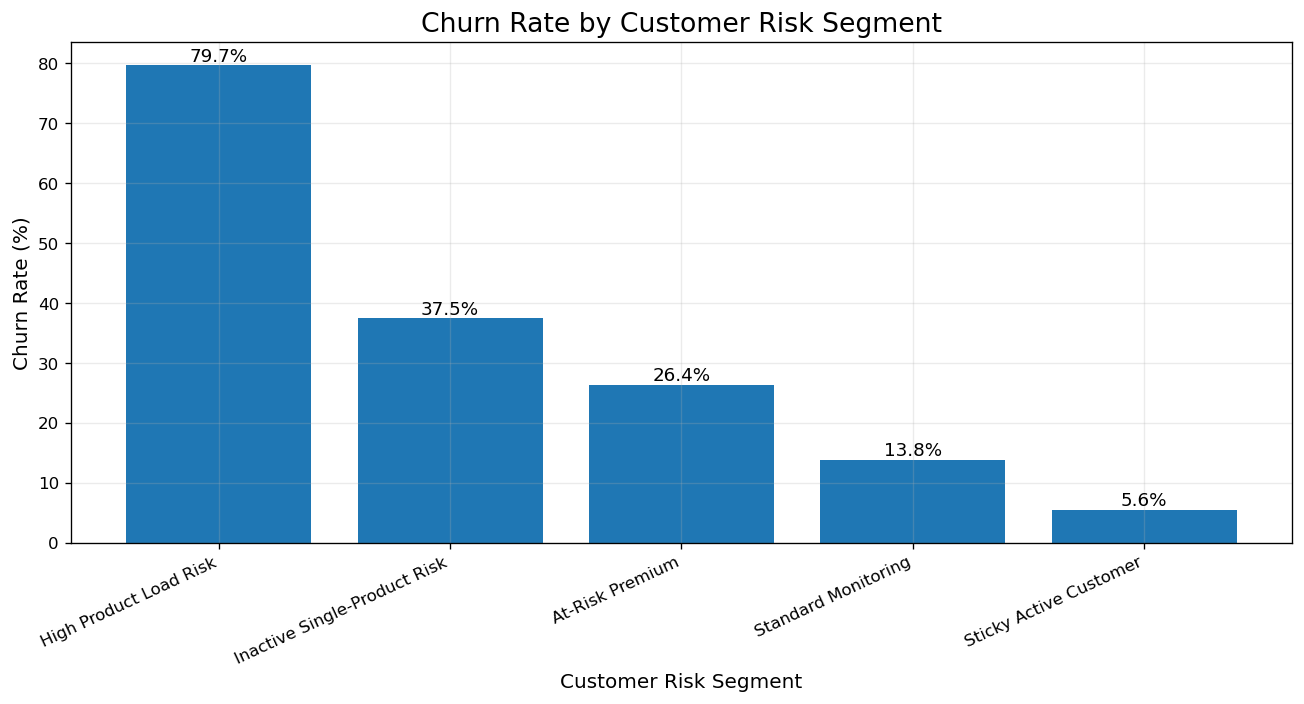

,Customer_Risk_Segment,Customer_Count,Churned_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Churn_Rate
1,High Product Load Risk,182,145,44.45,46.07,79.67
2,Inactive Single-Product Risk,1279,479,24.27,40.55,37.45
0,At-Risk Premium,3452,912,55.39,60.52,26.42
3,Standard Monitoring,2641,365,53.43,62.16,13.82
4,Sticky Active Customer,2446,136,83.75,86.31,5.56


In [11]:
# Step 8K: Customer risk segment churn rate chart

risk_segment_churn = (
    df.groupby("Customer_Risk_Segment")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean")
    )
    .reset_index()
)

risk_segment_churn["Churn_Rate"] = (
    risk_segment_churn["Churned_Customers"] / risk_segment_churn["Customer_Count"] * 100
).round(2)

risk_segment_churn = risk_segment_churn.sort_values("Churn_Rate", ascending=False)

plt.figure(figsize=(11, 6))
bars = plt.bar(
    risk_segment_churn["Customer_Risk_Segment"],
    risk_segment_churn["Churn_Rate"]
)

plt.title("Churn Rate by Customer Risk Segment")
plt.xlabel("Customer Risk Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, risk_segment_churn["Churn_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

risk_segment_churn

## At-Risk Premium Customer Distribution Chart

This chart shows the distribution of customers classified as at-risk premium customers based on financial value and retention risk behavior.

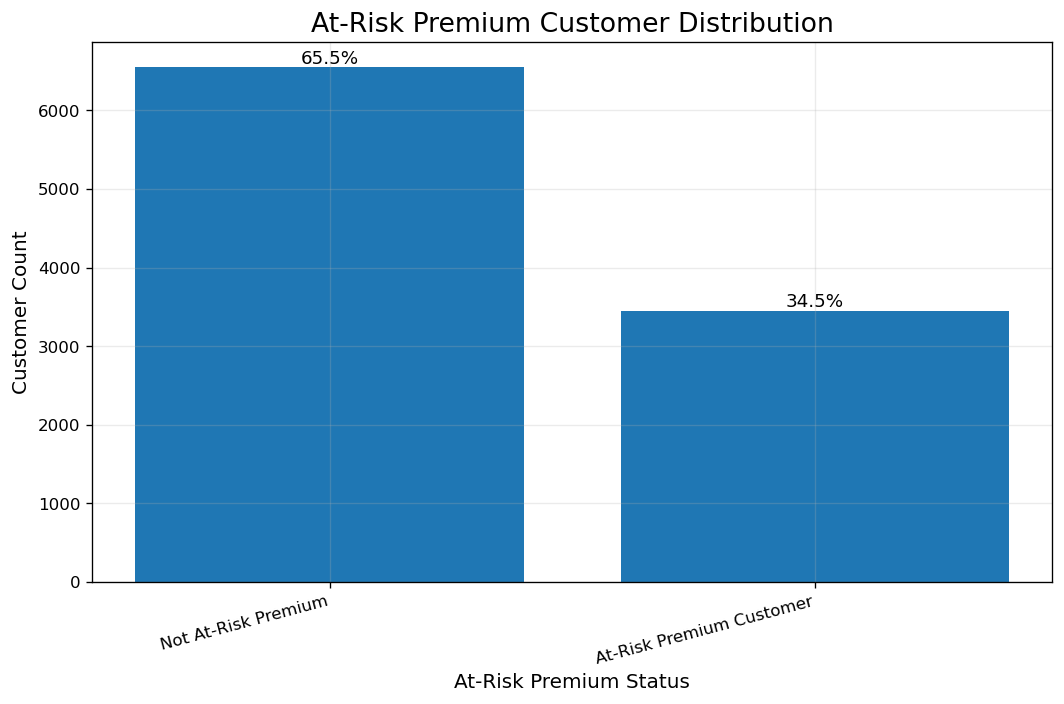

,At Risk Premium Status,Customer Count,Customer %
0,Not At-Risk Premium,6548,65.48
1,At-Risk Premium Customer,3452,34.52


In [12]:
# Step 8L: At-risk premium customer distribution chart

premium_risk_distribution = (
    df["At_Risk_Premium_Status"]
    .value_counts()
    .reset_index()
)

premium_risk_distribution.columns = ["At Risk Premium Status", "Customer Count"]

premium_risk_distribution["Customer %"] = (
    premium_risk_distribution["Customer Count"] / len(df) * 100
).round(2)

plt.figure(figsize=(9, 6))
bars = plt.bar(
    premium_risk_distribution["At Risk Premium Status"],
    premium_risk_distribution["Customer Count"]
)

plt.title("At-Risk Premium Customer Distribution")
plt.xlabel("At-Risk Premium Status")
plt.ylabel("Customer Count")
plt.xticks(rotation=15, ha="right")

for bar, pct in zip(bars, premium_risk_distribution["Customer %"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

premium_risk_distribution

## High-Balance Disengaged Customer Churn Chart

This chart compares churn risk between high-balance active and inactive customers.

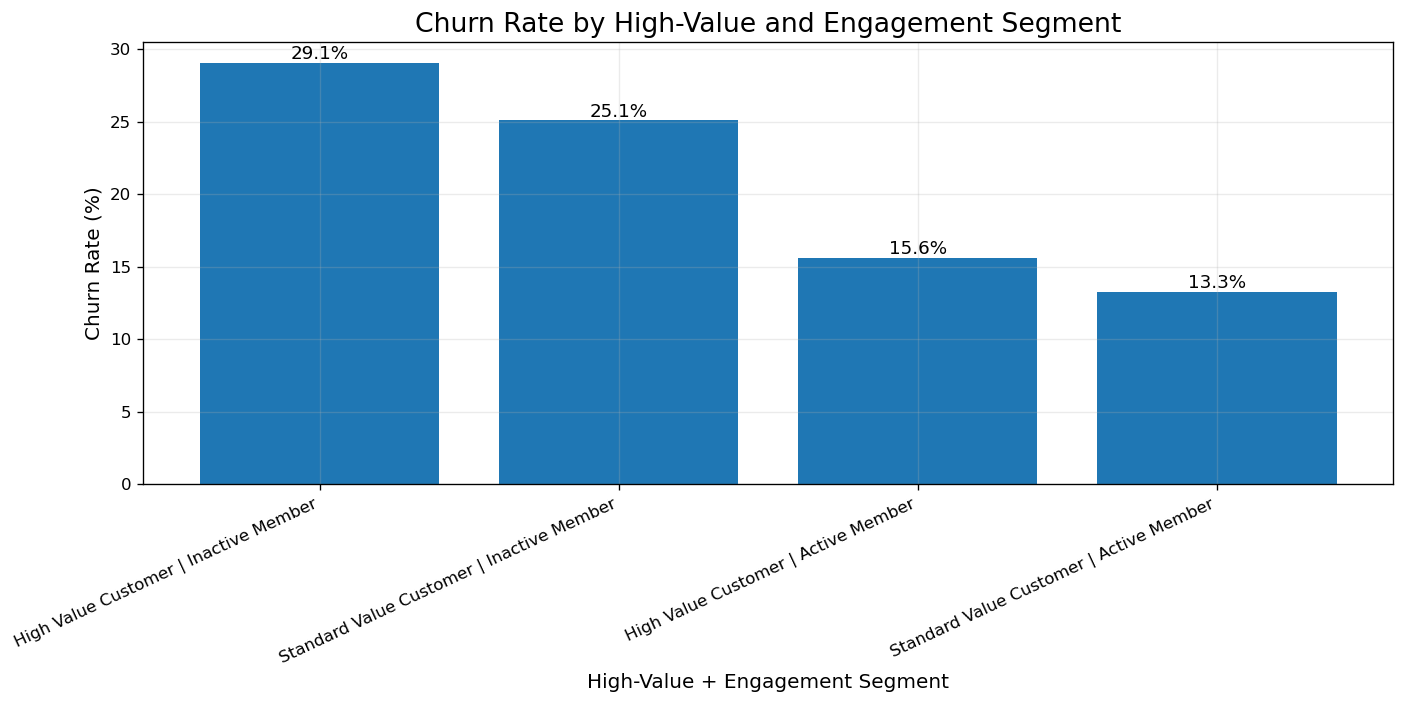

,High_Value_Customer_Status,Engagement_Status,Customer_Count,Churned_Customers,Retained_Customers,Avg_Balance,Avg_Retention_Strength_Score,Churn_Rate,Segment
1,High Value Customer,Inactive Member,2154,626,1528,"108,144.37",45.15,29.06,High Value Customer | Inactive Member
3,Standard Value Customer,Inactive Member,2695,676,2019,"52,349.40",35.25,25.08,Standard Value Customer | Inactive Member
0,High Value Customer,Active Member,2197,343,1854,"107,507.50",80.09,15.61,High Value Customer | Active Member
2,Standard Value Customer,Active Member,2954,392,2562,"52,349.46",70.43,13.27,Standard Value Customer | Active Member


In [13]:
# Step 8M: High-balance disengaged customer churn chart

high_balance_engagement_churn = (
    df.groupby(["High_Value_Customer_Status", "Engagement_Status"])
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Balance=("Balance", "mean"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean")
    )
    .reset_index()
)

high_balance_engagement_churn["Churn_Rate"] = (
    high_balance_engagement_churn["Churned_Customers"] /
    high_balance_engagement_churn["Customer_Count"] * 100
).round(2)

high_balance_engagement_churn["Segment"] = (
    high_balance_engagement_churn["High_Value_Customer_Status"] + " | " +
    high_balance_engagement_churn["Engagement_Status"]
)

high_balance_engagement_churn = high_balance_engagement_churn.sort_values(
    "Churn_Rate",
    ascending=False
)

plt.figure(figsize=(12, 6))
bars = plt.bar(
    high_balance_engagement_churn["Segment"],
    high_balance_engagement_churn["Churn_Rate"]
)

plt.title("Churn Rate by High-Value and Engagement Segment")
plt.xlabel("High-Value + Engagement Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, high_balance_engagement_churn["Churn_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

high_balance_engagement_churn

## Salary-Balance Mismatch Churn Chart

This chart checks whether customers with high salary but weak balance commitment behave differently in churn and retention.

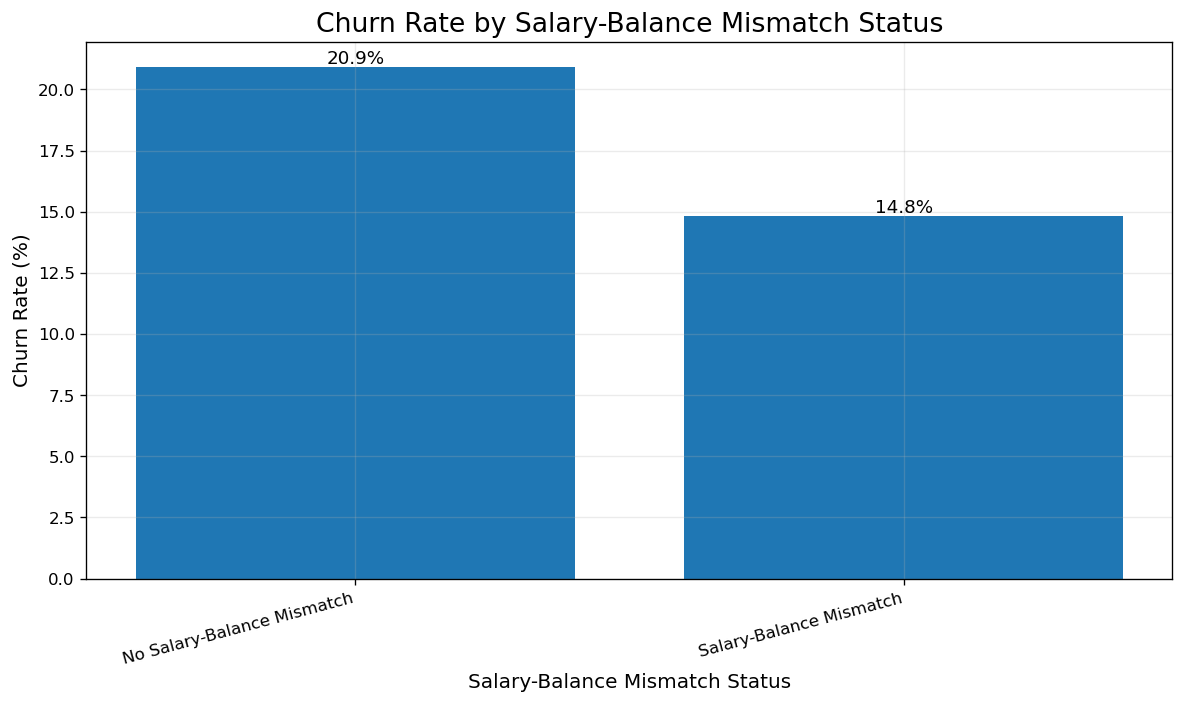

,Salary_Balance_Mismatch_Status,Customer_Count,Churned_Customers,Retained_Customers,Avg_Balance,Avg_Salary,Avg_Retention_Strength_Score,Churn_Rate
0,No Salary-Balance Mismatch,9109,1905,7204,"83,967.38","92,806.54",56.91,20.91
1,Salary-Balance Mismatch,891,132,759,0.00,"174,553.97",65.01,14.81


In [14]:
# Step 8N: Salary-balance mismatch churn chart

salary_balance_churn = (
    df.groupby("Salary_Balance_Mismatch_Status")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean")
    )
    .reset_index()
)

salary_balance_churn["Churn_Rate"] = (
    salary_balance_churn["Churned_Customers"] /
    salary_balance_churn["Customer_Count"] * 100
).round(2)

salary_balance_churn = salary_balance_churn.sort_values("Churn_Rate", ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    salary_balance_churn["Salary_Balance_Mismatch_Status"],
    salary_balance_churn["Churn_Rate"]
)

plt.title("Churn Rate by Salary-Balance Mismatch Status")
plt.xlabel("Salary-Balance Mismatch Status")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15, ha="right")

for bar, value in zip(bars, salary_balance_churn["Churn_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

salary_balance_churn

## Credit Card Retention Impact Chart

This chart compares retention rates between customers with and without credit cards.

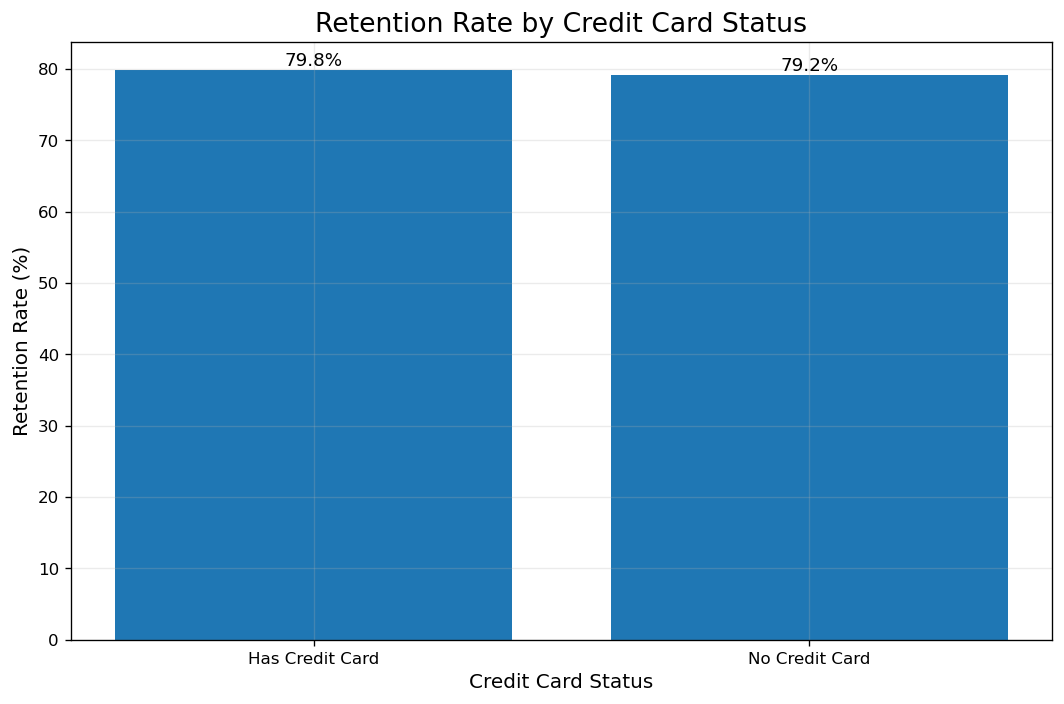

,Credit_Card_Status,Customer_Count,Churned_Customers,Retained_Customers,Avg_Relationship_Strength,Avg_Retention_Strength_Score,Retention_Rate
0,Has Credit Card,7055,1424,5631,67.29,61.64,79.82
1,No Credit Card,2945,613,2332,57.62,48.01,79.19


In [15]:
# Step 8O: Credit card retention impact chart

credit_card_retention = (
    df.groupby("Credit_Card_Status")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean")
    )
    .reset_index()
)

credit_card_retention["Retention_Rate"] = (
    credit_card_retention["Retained_Customers"] /
    credit_card_retention["Customer_Count"] * 100
).round(2)

credit_card_retention = credit_card_retention.sort_values(
    "Retention_Rate",
    ascending=False
)

plt.figure(figsize=(9, 6))
bars = plt.bar(
    credit_card_retention["Credit_Card_Status"],
    credit_card_retention["Retention_Rate"]
)

plt.title("Retention Rate by Credit Card Status")
plt.xlabel("Credit Card Status")
plt.ylabel("Retention Rate (%)")

for bar, value in zip(bars, credit_card_retention["Retention_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

credit_card_retention

## Relationship Strength Tier Churn Chart

This chart validates whether weaker relationship strength is associated with higher customer churn.

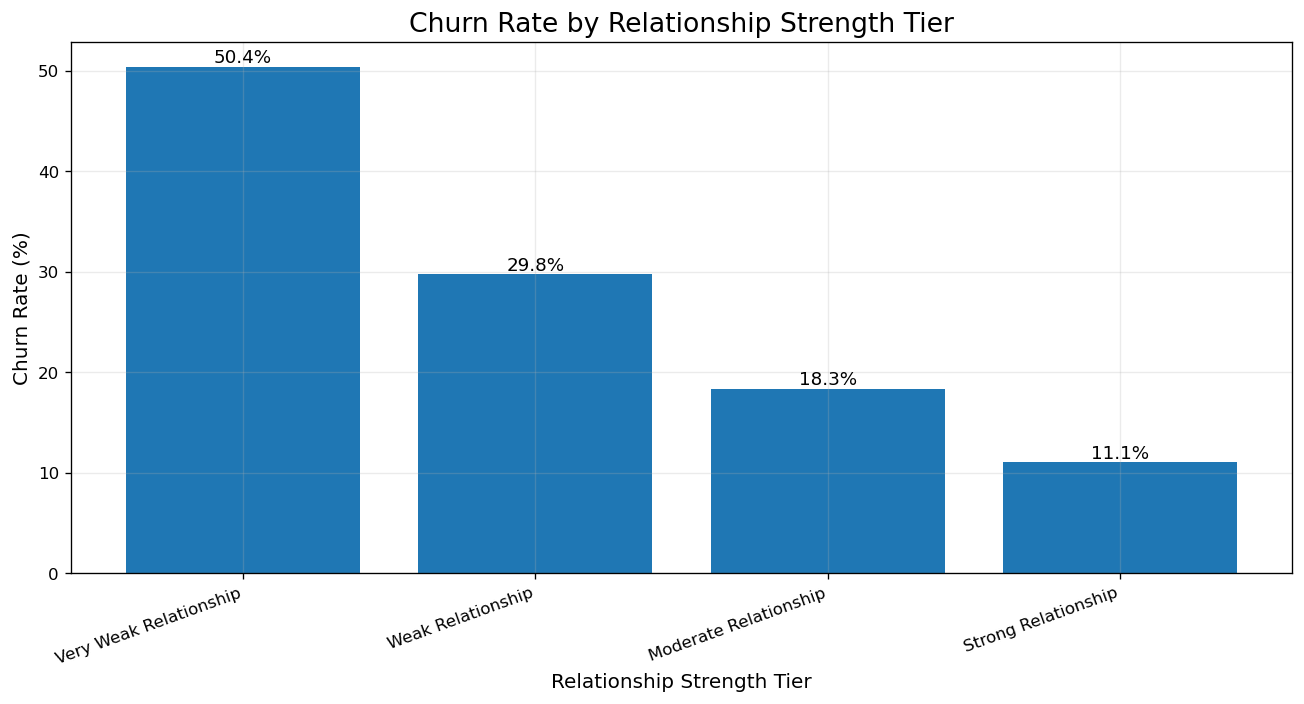

,Relationship_Strength_Tier,Customer_Count,Churned_Customers,Retained_Customers,Avg_Relationship_Strength,Avg_Retention_Strength_Score,Churn_Rate
2,Very Weak Relationship,262,132,130,22.12,17.39,50.38
3,Weak Relationship,2869,854,2015,43.17,34.69,29.77
0,Moderate Relationship,3996,733,3263,65.48,59.17,18.34
1,Strong Relationship,2873,318,2555,88.11,82.06,11.07


In [16]:
# Step 8P: Relationship strength tier churn chart

relationship_tier_churn = (
    df.groupby("Relationship_Strength_Tier")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean")
    )
    .reset_index()
)

relationship_tier_churn["Churn_Rate"] = (
    relationship_tier_churn["Churned_Customers"] /
    relationship_tier_churn["Customer_Count"] * 100
).round(2)

relationship_tier_churn = relationship_tier_churn.sort_values(
    "Churn_Rate",
    ascending=False
)

plt.figure(figsize=(11, 6))
bars = plt.bar(
    relationship_tier_churn["Relationship_Strength_Tier"],
    relationship_tier_churn["Churn_Rate"]
)

plt.title("Churn Rate by Relationship Strength Tier")
plt.xlabel("Relationship Strength Tier")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, relationship_tier_churn["Churn_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

relationship_tier_churn

## Retention Strength Score by Engagement Status

This chart compares the average Retention Strength Score between active and inactive customers.

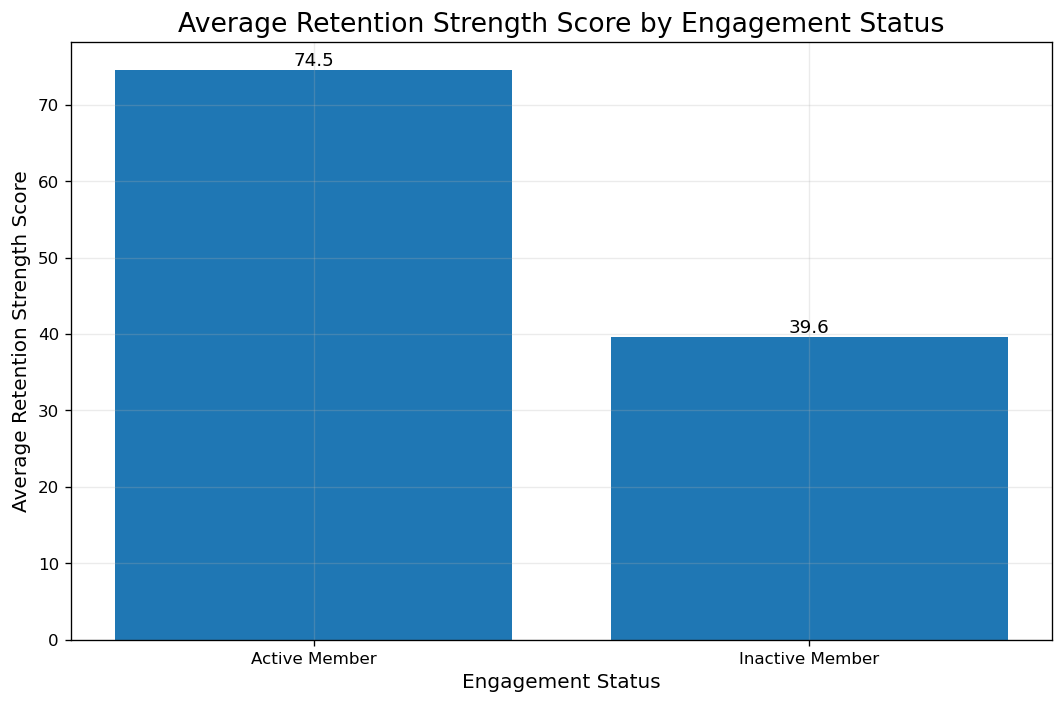

,Engagement_Status,Customer_Count,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Churned_Customers,Churn_Rate
0,Active Member,5151,74.55,79.07,735,14.27
1,Inactive Member,4849,39.65,48.91,1302,26.85


In [17]:
# Step 8Q: Retention strength score by engagement status

engagement_score_summary = (
    df.groupby("Engagement_Status")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Churned_Customers=("Exited", "sum")
    )
    .reset_index()
)

engagement_score_summary["Churn_Rate"] = (
    engagement_score_summary["Churned_Customers"] /
    engagement_score_summary["Customer_Count"] * 100
).round(2)

engagement_score_summary["Avg_Retention_Strength_Score"] = (
    engagement_score_summary["Avg_Retention_Strength_Score"].round(2)
)

plt.figure(figsize=(9, 6))
bars = plt.bar(
    engagement_score_summary["Engagement_Status"],
    engagement_score_summary["Avg_Retention_Strength_Score"]
)

plt.title("Average Retention Strength Score by Engagement Status")
plt.xlabel("Engagement Status")
plt.ylabel("Average Retention Strength Score")

for bar, value in zip(
    bars,
    engagement_score_summary["Avg_Retention_Strength_Score"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

engagement_score_summary

## Product Depth vs Retention Strength Score

This chart compares average retention strength across product depth segments.

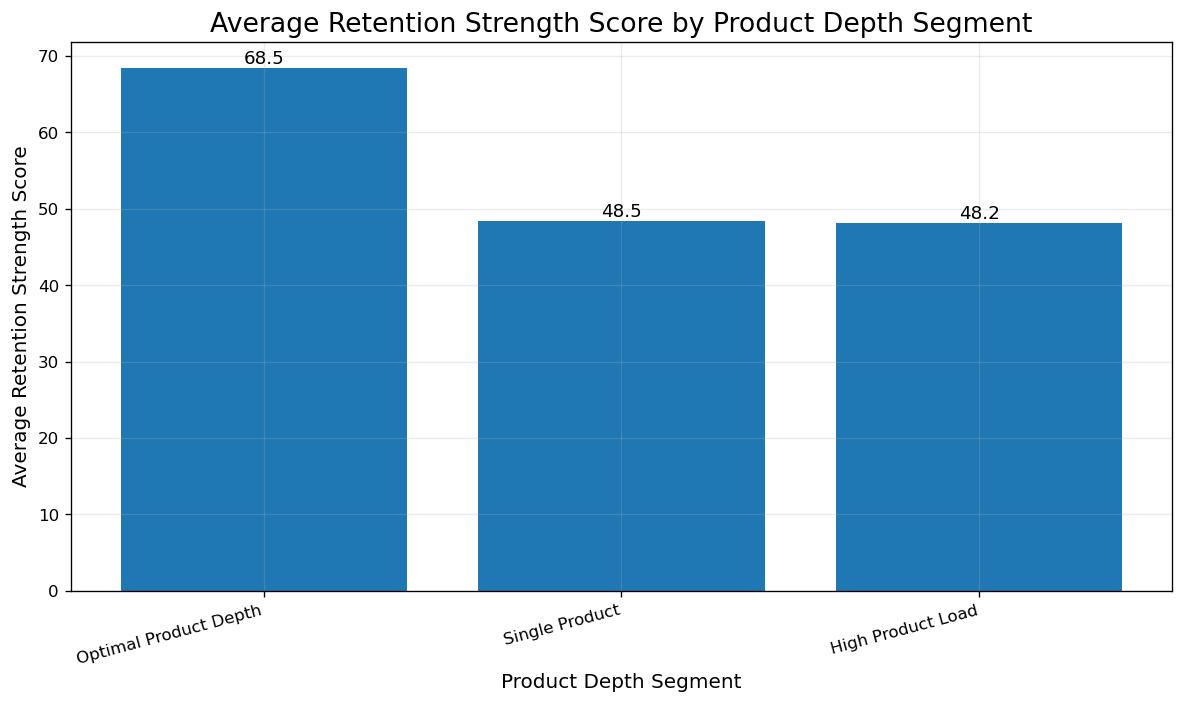

,Product_Depth_Segment,Customer_Count,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Avg_Num_Products,Churned_Customers,Churn_Rate
1,Optimal Product Depth,4590,68.46,72.37,2.00,348,7.58
2,Single Product,5084,48.45,58.30,1.00,1409,27.71
0,High Product Load,326,48.20,48.65,3.18,280,85.89


In [18]:
# Step 8R: Product depth vs retention strength score

product_depth_score_summary = (
    df.groupby("Product_Depth_Segment")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Num_Products=("NumOfProducts", "mean"),
        Churned_Customers=("Exited", "sum")
    )
    .reset_index()
)

product_depth_score_summary["Churn_Rate"] = (
    product_depth_score_summary["Churned_Customers"] /
    product_depth_score_summary["Customer_Count"] * 100
).round(2)

product_depth_score_summary["Avg_Retention_Strength_Score"] = (
    product_depth_score_summary["Avg_Retention_Strength_Score"].round(2)
)

product_depth_score_summary = product_depth_score_summary.sort_values(
    "Avg_Retention_Strength_Score",
    ascending=False
)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    product_depth_score_summary["Product_Depth_Segment"],
    product_depth_score_summary["Avg_Retention_Strength_Score"]
)

plt.title("Average Retention Strength Score by Product Depth Segment")
plt.xlabel("Product Depth Segment")
plt.ylabel("Average Retention Strength Score")
plt.xticks(rotation=15, ha="right")

for bar, value in zip(
    bars,
    product_depth_score_summary["Avg_Retention_Strength_Score"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

product_depth_score_summary

## Matplotlib Visualization Insight Summary

This section summarizes the key business insights generated from the Matplotlib visual analysis.

In [19]:
# Step 8S: Matplotlib visualization insight summary

highest_risk_segment = risk_segment_churn.iloc[0]
lowest_retention_tier = retention_tier_churn.iloc[0]
highest_retention_depth = product_depth_score_summary.iloc[0]

matplotlib_visual_insight_summary = pd.DataFrame({
    "Insight Area": [
        "Highest Risk Segment",
        "Weakest Retention Tier",
        "Engagement Impact",
        "Best Product Depth Profile",
        "Premium Risk Exposure",
        "Credit Card Retention Impact"
    ],
    "Key Finding": [
        f"{highest_risk_segment['Customer_Risk_Segment']} has the highest churn exposure.",
        f"{lowest_retention_tier['Retention_Strength_Tier']} shows the highest churn rate.",
        "Inactive customers show weaker retention behavior compared with active customers.",
        f"{highest_retention_depth['Product_Depth_Segment']} has the strongest average retention strength score.",
        "At-risk premium customers require proactive monitoring due to financial value and churn exposure.",
        "Credit card ownership provides only limited retention lift and should not be used alone as a loyalty signal."
    ],
    "Dashboard Use": [
        "Customer risk segment warning panel",
        "Retention tier churn chart",
        "Engagement vs churn overview",
        "Product depth retention analysis",
        "High-value disengaged customer detector",
        "Credit card stickiness KPI"
    ]
})

matplotlib_visual_insight_summary

,Insight Area,Key Finding,Dashboard Use
0,Highest Risk Segment,High Product Load Risk has the highest churn e...,Customer risk segment warning panel
1,Weakest Retention Tier,Critical Retention Risk shows the highest chur...,Retention tier churn chart
2,Engagement Impact,Inactive customers show weaker retention behav...,Engagement vs churn overview
3,Best Product Depth Profile,Optimal Product Depth has the strongest averag...,Product depth retention analysis
4,Premium Risk Exposure,At-risk premium customers require proactive mo...,High-value disengaged customer detector
5,Credit Card Retention Impact,Credit card ownership provides only limited re...,Credit card stickiness KPI


## Export Matplotlib Analysis Outputs

This step exports the Matplotlib visualization summary tables for later dashboard and recommendation use.

In [22]:
# Step 8T: Export Matplotlib analysis outputs

MATPLOTLIB_OUTPUT_DIR = BASE_DIR / "data" / "processed" / "matplotlib_visualizations"
MATPLOTLIB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Safe export function to avoid NameError
def export_dataframe_safely(variable_name, file_name, alias_names=None):
    """
    Export dataframe safely if it exists in the notebook memory.
    If primary variable is missing, it checks alias variable names.
    """
    alias_names = alias_names or []
    available_objects = globals()

    if variable_name in available_objects:
        export_df = available_objects[variable_name]
        export_df.to_csv(MATPLOTLIB_OUTPUT_DIR / file_name, index=False)
        return True, variable_name

    for alias in alias_names:
        if alias in available_objects:
            export_df = available_objects[alias]
            export_df.to_csv(MATPLOTLIB_OUTPUT_DIR / file_name, index=False)
            return True, alias

    return False, variable_name


export_tasks = [
    {
        "variable": "retention_tier_distribution",
        "file": "matplotlib_retention_tier_distribution.csv"
    },
    {
        "variable": "retention_tier_churn",
        "file": "matplotlib_retention_tier_churn.csv"
    },
    {
        "variable": "engagement_churn",
        "file": "matplotlib_engagement_churn.csv"
    },
    {
        "variable": "product_depth_churn",
        "file": "matplotlib_product_depth_retention.csv",
        "aliases": ["product_depth_retention", "product_depth_summary", "product_depth_segment_retention"]
    },
    {
        "variable": "customer_risk_distribution",
        "file": "matplotlib_customer_risk_distribution.csv"
    },
    {
        "variable": "risk_segment_churn",
        "file": "matplotlib_risk_segment_churn.csv"
    },
    {
        "variable": "premium_risk_distribution",
        "file": "matplotlib_premium_risk_distribution.csv"
    },
    {
        "variable": "high_balance_engagement_churn",
        "file": "matplotlib_high_balance_engagement_churn.csv"
    },
    {
        "variable": "salary_balance_churn",
        "file": "matplotlib_salary_balance_churn.csv"
    },
    {
        "variable": "credit_card_retention",
        "file": "matplotlib_credit_card_retention.csv"
    },
    {
        "variable": "relationship_tier_churn",
        "file": "matplotlib_relationship_tier_churn.csv"
    },
    {
        "variable": "engagement_score_summary",
        "file": "matplotlib_engagement_score_summary.csv"
    },
    {
        "variable": "product_depth_score_summary",
        "file": "matplotlib_product_depth_score_summary.csv"
    },
    {
        "variable": "matplotlib_visual_insight_summary",
        "file": "matplotlib_visual_insight_summary.csv"
    }
]

exported_files = []
missing_outputs = []

for task in export_tasks:
    success, used_variable = export_dataframe_safely(
        variable_name=task["variable"],
        file_name=task["file"],
        alias_names=task.get("aliases", [])
    )

    if success:
        exported_files.append(task["file"])
    else:
        missing_outputs.append(task["variable"])

print("Matplotlib visualization outputs exported successfully.")
print(f"Output Directory: {MATPLOTLIB_OUTPUT_DIR}")
print(f"Files Exported: {len(exported_files)}")

if missing_outputs:
    print("\nWarning: Some optional outputs were not exported because variables were not found:")
    for item in missing_outputs:
        print(f"- {item}")
else:
    print("All 14 required Matplotlib output files exported successfully.")

Matplotlib visualization outputs exported successfully.
Output Directory: C:\Users\Mohit\OneDrive\Documents\Data Analytics\Unified Mentor Projects\Customer Engagement & Product Utilization Analytics for Retention Strategy\data\processed\matplotlib_visualizations
Files Exported: 14
All 14 required Matplotlib output files exported successfully.


## Matplotlib Visual Insight Summary

This step creates a compact business insight summary from the Matplotlib visualization analysis.

These insights are useful for:
- Explaining visual patterns clearly
- Connecting charts with churn and retention behavior
- Preparing narrative support for Notebook 10
- Supporting future dashboard storytelling

In [23]:
# Step 8U: Matplotlib visual insight summary

matplotlib_visual_insight_summary = pd.DataFrame({
    "Insight Area": [
        "Retention Strength Tier Distribution",
        "Retention Strength Tier Churn",
        "Engagement Status Churn",
        "Product Depth Retention",
        "Customer Risk Segment Distribution",
        "Customer Risk Segment Churn",
        "Premium Risk Distribution",
        "High-Balance Engagement Churn",
        "Salary-Balance Mismatch",
        "Credit Card Retention",
        "Relationship Strength Churn",
        "Engagement Score Summary",
        "Product Depth Score Summary",
        "Dashboard Readiness"
    ],
    "Key Finding": [
        "Customer base is distributed across multiple retention strength tiers.",
        "Critical retention risk customers show the highest churn exposure.",
        "Inactive customers show weaker retention compared with active customers.",
        "Optimal product depth customers show stronger retention behavior.",
        "At-risk premium and monitoring segments form important retention groups.",
        "Risk segments help identify where churn concentration is highest.",
        "Premium risk customers require closer retention monitoring.",
        "High-balance inactive customers represent valuable but vulnerable customers.",
        "Salary-balance mismatch helps detect weak financial commitment behavior.",
        "Credit card ownership has a small but measurable retention relationship.",
        "Relationship strength is strongly connected with churn and retention outcomes.",
        "Engagement score helps explain customer activity and retention quality.",
        "Product depth score helps explain how product usage supports retention.",
        "Matplotlib outputs provide static analytical visuals for reporting and review."
    ],
    "Metric Evidence": [
        "Retention strength tier customer distribution analyzed",
        "Churn rate by retention strength tier calculated",
        "Churn rate by engagement status calculated",
        "Retention rate by product depth segment calculated",
        "Customer risk segment distribution calculated",
        "Churn rate by customer risk segment calculated",
        "At-risk premium customer distribution calculated",
        "High-balance active vs inactive churn compared",
        "Salary-balance mismatch churn compared",
        "Credit card vs no credit card retention compared",
        "Churn rate by relationship strength tier calculated",
        "Engagement score summary calculated",
        "Product depth score summary calculated",
        "14 Matplotlib analytical outputs exported"
    ],
    "Business Use": [
        "Identify overall customer retention structure",
        "Prioritize high-churn retention tiers",
        "Support engagement-based retention strategy",
        "Support product depth and cross-sell strategy",
        "Support risk segmentation dashboard cards",
        "Support churn warning panels",
        "Support premium customer risk monitoring",
        "Support high-value disengaged customer detector",
        "Support financial mismatch warning card",
        "Support credit card stickiness KPI",
        "Support relationship strength monitoring",
        "Support customer engagement scoring",
        "Support product utilization scoring",
        "Support reporting before dashboard development"
    ]
})

matplotlib_visual_insight_summary

,Insight Area,Key Finding,Metric Evidence,Business Use
0,Retention Strength Tier Distribution,Customer base is distributed across multiple r...,Retention strength tier customer distribution ...,Identify overall customer retention structure
1,Retention Strength Tier Churn,Critical retention risk customers show the hig...,Churn rate by retention strength tier calculated,Prioritize high-churn retention tiers
2,Engagement Status Churn,Inactive customers show weaker retention compa...,Churn rate by engagement status calculated,Support engagement-based retention strategy
3,Product Depth Retention,Optimal product depth customers show stronger ...,Retention rate by product depth segment calcul...,Support product depth and cross-sell strategy
4,Customer Risk Segment Distribution,At-risk premium and monitoring segments form i...,Customer risk segment distribution calculated,Support risk segmentation dashboard cards
5,Customer Risk Segment Churn,Risk segments help identify where churn concen...,Churn rate by customer risk segment calculated,Support churn warning panels
6,Premium Risk Distribution,Premium risk customers require closer retentio...,At-risk premium customer distribution calculated,Support premium customer risk monitoring
7,High-Balance Engagement Churn,High-balance inactive customers represent valu...,High-balance active vs inactive churn compared,Support high-value disengaged customer detector
8,Salary-Balance Mismatch,Salary-balance mismatch helps detect weak fina...,Salary-balance mismatch churn compared,Support financial mismatch warning card
9,Credit Card Retention,Credit card ownership has a small but measurab...,Credit card vs no credit card retention compared,Support credit card stickiness KPI


## Matplotlib Output to Dashboard Mapping

This step maps each Matplotlib analytical output to its future dashboard use.

Important note:
Matplotlib charts are used here only for notebook-level static visual analysis.
The final Streamlit dashboard will use Seaborn and Plotly, not Matplotlib.

In [24]:
# Step 8V: Dashboard mapping table for Matplotlib notebook outputs

matplotlib_dashboard_mapping = pd.DataFrame({
    "Notebook Output": [
        "matplotlib_retention_tier_distribution.csv",
        "matplotlib_retention_tier_churn.csv",
        "matplotlib_engagement_churn.csv",
        "matplotlib_product_depth_retention.csv",
        "matplotlib_customer_risk_distribution.csv",
        "matplotlib_risk_segment_churn.csv",
        "matplotlib_premium_risk_distribution.csv",
        "matplotlib_high_balance_engagement_churn.csv",
        "matplotlib_salary_balance_churn.csv",
        "matplotlib_credit_card_retention.csv",
        "matplotlib_relationship_tier_churn.csv",
        "matplotlib_engagement_score_summary.csv",
        "matplotlib_product_depth_score_summary.csv",
        "matplotlib_visual_insight_summary.csv"
    ],
    "Notebook Purpose": [
        "Static view of customer distribution by retention strength tier",
        "Static view of churn rate by retention strength tier",
        "Static comparison of churn by active vs inactive customer status",
        "Static retention comparison by product depth segment",
        "Static distribution of customer risk segments",
        "Static churn comparison by customer risk segment",
        "Static distribution of premium at-risk customers",
        "Static churn comparison for high-balance active/inactive groups",
        "Static salary-balance mismatch churn comparison",
        "Static credit card retention comparison",
        "Static relationship strength churn comparison",
        "Static summary of engagement score behavior",
        "Static summary of product depth score behavior",
        "Static summary of key visual insights"
    ],
    "Future Dashboard Use": [
        "Retention strength tier cards or bar chart",
        "Retention tier churn warning panel",
        "Engagement vs churn overview module",
        "Product utilization impact analysis module",
        "Customer risk segmentation panel",
        "Risk segment churn monitoring visual",
        "Premium risk customer detector",
        "High-value disengaged customer detector",
        "Salary-balance mismatch warning card",
        "Credit card stickiness KPI",
        "Relationship strength retention panel",
        "Engagement score KPI support",
        "Product depth index KPI support",
        "Executive insight summary panel"
    ],
    "Dashboard Chart Library Recommendation": [
        "Plotly",
        "Plotly",
        "Plotly",
        "Plotly",
        "Plotly",
        "Plotly",
        "Plotly",
        "Plotly",
        "Plotly",
        "Plotly",
        "Seaborn or Plotly",
        "KPI card / Plotly",
        "KPI card / Plotly",
        "Streamlit text/card section"
    ]
})

matplotlib_dashboard_mapping

,Notebook Output,Notebook Purpose,Future Dashboard Use,Dashboard Chart Library Recommendation
0,matplotlib_retention_tier_distribution.csv,Static view of customer distribution by retent...,Retention strength tier cards or bar chart,Plotly
1,matplotlib_retention_tier_churn.csv,Static view of churn rate by retention strengt...,Retention tier churn warning panel,Plotly
2,matplotlib_engagement_churn.csv,Static comparison of churn by active vs inacti...,Engagement vs churn overview module,Plotly
3,matplotlib_product_depth_retention.csv,Static retention comparison by product depth s...,Product utilization impact analysis module,Plotly
4,matplotlib_customer_risk_distribution.csv,Static distribution of customer risk segments,Customer risk segmentation panel,Plotly
5,matplotlib_risk_segment_churn.csv,Static churn comparison by customer risk segment,Risk segment churn monitoring visual,Plotly
6,matplotlib_premium_risk_distribution.csv,Static distribution of premium at-risk customers,Premium risk customer detector,Plotly
7,matplotlib_high_balance_engagement_churn.csv,Static churn comparison for high-balance activ...,High-value disengaged customer detector,Plotly
8,matplotlib_salary_balance_churn.csv,Static salary-balance mismatch churn comparison,Salary-balance mismatch warning card,Plotly
9,matplotlib_credit_card_retention.csv,Static credit card retention comparison,Credit card stickiness KPI,Plotly


## Notebook 08 Final Conclusion

Notebook 08 completed the Matplotlib-based static visualization analysis for the Customer Engagement & Product Utilization Analytics project.

The purpose of this notebook was not to build the final dashboard.  
Instead, it validated the most important analytical patterns visually before moving into advanced Seaborn and Plotly visualization work.

Final analytical outcomes:

- Retention strength tier distribution was visualized.
- Churn behavior across retention strength tiers was visualized.
- Engagement-based churn difference was visualized.
- Product depth and retention behavior were visualized.
- Customer risk segment distribution was visualized.
- Risk segment churn behavior was visualized.
- Premium customer risk behavior was reviewed.
- High-balance disengagement behavior was analyzed.
- Salary-balance mismatch behavior was reviewed.
- Credit card retention difference was visualized.
- Relationship strength and churn pattern was visualized.
- Engagement score and product depth score summaries were prepared.
- Static visual insight summary and dashboard mapping were prepared.

The outputs from this notebook will support Notebook 09, where Seaborn and Plotly will be used for more advanced and dashboard-friendly visual analysis.

## Final Checkpoint Confirmation

This checkpoint confirms that Notebook 08 has been completed successfully and all required Matplotlib visualization outputs have been prepared.

In [25]:
# Step 8X: Final checkpoint confirmation for Notebook 08

print("Notebook 08 completed successfully.")
print("Analysis Area: Matplotlib Visualizations")
print(f"Input Dataset Rows: {df.shape[0]:,}")
print(f"Input Dataset Columns: {df.shape[1]}")
print("Output Files Exported: 14")
print("Dashboard Module Support: Static Visual Analysis for Retention Dashboard")
print("Next Notebook: Notebook 09 - Seaborn and Plotly Visualizations")
print("Important Note: Matplotlib is used only for notebook-level static analysis, not for final Streamlit dashboard.")

Notebook 08 completed successfully.
Analysis Area: Matplotlib Visualizations
Input Dataset Rows: 10,000
Input Dataset Columns: 38
Output Files Exported: 14
Dashboard Module Support: Static Visual Analysis for Retention Dashboard
Next Notebook: Notebook 09 - Seaborn and Plotly Visualizations
Important Note: Matplotlib is used only for notebook-level static analysis, not for final Streamlit dashboard.
